In [ ]:
# extract
import numpy as np
from numpy import linalg as LA

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

class VGGNet:
    def __init__(self):
        self.input_shape = (224, 224, 3)
        self.weight = 'imagenet'
        self.pooling = 'max'
        self.model = VGG16(weights = self.weight, input_shape = (self.input_shape[0], self.input_shape[1], self.input_shape[2]), pooling = self.pooling, include_top = False)
        self.model.predict(np.zeros((1, 224, 224 , 3)))

    def extract_feat(self, img_path):
        img = image.load_img(img_path, target_size=(self.input_shape[0], self.input_shape[1]))
        img = image.img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        feat = self.model.predict(img)
        norm_feat = feat[0]/LA.norm(feat[0])
        return norm_feat
    
# model = VGG16(weights = 'imagenet',
#               input_shape = ((224, 224, 3)),
#               pooling = 'max',
#               include_top = False)
# model.summary()


In [12]:
from google.colab import drive
drive.mount('/content/gdrive')
base_path = "/content/gdrive/MyDrive/ml/train/"

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [15]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
from scipy import spatial

In [23]:
h5f = h5py.File("/content/gdrive/MyDrive/ml/vgg/VGG16Features.h5", 'r')
feats = h5f['dataset_1'][:]
imgNames = h5f['dataset_2'][:]
h5f.close()

model = VGGNet()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/77.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/58.tour_img-1452539-146.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/5.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/78.colosseum.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/34.rome-colosseum-list.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/15.rome-colosseum-for-kids_colosseum-min.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/71.colosseum-2340415_1920.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/8.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/72.CIV_56NewImg0611D_lg.jpg
/content/gdrive/MyDrive/ml/train/Roman Colosseum - Rome/32.The-Colosseum-or-Flavian-Amphitheater-1024x339.jpg


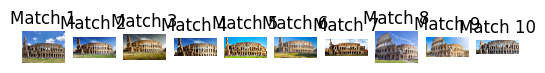

In [26]:
queryImg = "77.jpg"
X = model.extract_feat(queryImg)

scores = []
for i in range(feats.shape[0]):
    score = 1 - spatial.distance.cosine(X, feats[i])
    scores.append(score)
scores = np.array(scores)

rank_ID = np.argsort(scores)[::-1]
rank_score = scores[rank_ID]

maxres = 10
imlist = [imgNames[index].decode('utf-8') for index in rank_ID[0:maxres]]

for i, img_name in enumerate(imlist):
    img_path = os.path.join(base_path, img_name)
    print(img_path)
    img = plt.imread(img_path)
    plt.subplot(1, maxres, i+1)
    plt.imshow(img)
    plt.title(f"Match {i+1}")
    plt.axis('off')
plt.show()